In [69]:
import torch
from utils import solve_riccati
import numpy as np
from network import PhiNetwork, ScoreNetwork
from utils import batched_jacobian, rollout
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
T = 1.0  # End time
n = 1    # Dimension of state space
m = 1    # Dimension of Brownian motion
N = 50000 # Number of training samples
dt = 0.02  # Time step size
steps = int(T/dt)  # Number of time steps
noise_level = 2  # Noise level in the SDE
temperature_list = [50.0, 20.0, 8.0, 6.0, 1.0]
# temperature = 6.0

In [3]:
score_nn = ScoreNetwork(input_dim=n+1, out_dim=n, hidden_dim=32, num_blocks=2)
score_nn.load_state_dict(torch.load(f'network/toy_score_network_timesteps{steps}_v2.pth'))

/var/folders/pd/hp6m3j2j5v9bd6w64h7wl3rm0000gn/T/ipykernel_88978/2318091960.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  score_nn.load_state_dict(torch.load(f'network

<All keys matched successfully>

In [4]:
def g(x):
    """
    Diffusion function of X_t for a nonlinear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Diffusion matrix. Shape (N, n, m)
    """
    B = torch.tensor([[1.0]]) * noise_level
    B = B.unsqueeze(0).repeat(x.shape[0], 1, 1)
    return B

def f(x, t, u_t=None):
    """
    Drift function of X_t for a nonlinear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
        t (torch.Tensor): torch.tensor of shape (1,): Current time
        score_nn (ScoreNetwork): Neural network for score function
        # u_t (ScoreNetwork): Neural network for feedback control law --- IGNORE ---
        u_t (torch.Tensor): control inputs at each time step for each sample. Shape (steps+1, N, m)
    Returns:
        torch.Tensor: Drift vector. Shape (N, n)
    """
    a = 2
    u = u_t(x, t.repeat(x.shape[0], 1)) if u_t is not None else torch.zeros(m)  # shape (N, m)
    gu = torch.einsum('nij,nj->ni', g(x), u)  if u_t is not None else torch.zeros_like(x) # shape (N, n)
    # u = u_t[int(t/dt)] if u_t is not None else torch.zeros((N, m))  # shape (N, m) make sure use u at the right time step
    # gu = torch.einsum('nij,nj->ni', g(x), u) # shape (N, n)
    df = a * x + noise_level**2 * score_nn(x, (T - t).repeat(x.shape[0], 1)) + gu
    return df

def lf(x):
    """
    Terminal cost function for a linear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Terminal cost. Shape (N,)
    """
    return 0.5 *(x - 3.0)**2

In [5]:
class UNetFromPhi(torch.nn.Module):
    def __init__(self, phi_net, g_fn, temperature):
        super().__init__()
        self.phi_net = phi_net      # nn.Module
        self.g_fn = g_fn            # function: (N,n) -> (N,n,m)
        self.temperature = temperature

    def forward(self, x, t):
        # x: (N,n), t: (N,1)
        y = self.phi_net(x, t)          # (N,n)
        gx = self.g_fn(x)               # (N,n,m)
        u = -torch.einsum('nim,ni->nm', gx, y) / self.temperature  # (N,m) = -g(x)^T y / temperature
        return u

In [13]:
time_grid = torch.arange(0, steps+1) * dt
time_repeated = time_grid.repeat(N, 1).T # shape (steps+1, N)

In [15]:
def original_pdf(x):
    m1 = 3.0
    m2 = -3.0
    sigma = 1.0
    p1 = torch.exp(-0.5 * ((x - m1) / sigma)**2) / (sigma * torch.sqrt(torch.tensor(2.0) * torch.pi))
    p2 = torch.exp(-0.5 * ((x - m2) / sigma)**2) / (sigma * torch.sqrt(torch.tensor(2.0) * torch.pi))
    return 0.5 * (p1 + p2)

def tilted_pdf(x, temperature):
    return original_pdf(x)*torch.exp(-(x-3.0)**2/(2*temperature))

In [124]:
import matplotlib

plt.rc('font', size = 14)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [125]:
temperature = 50.0
phi_iter = 5
Q_am = torch.load(f'network/finetune_admatching_Q_timesteps{steps}_utiter{phi_iter}_optiter{1000}_iteration{30}_temperature{temperature}_initialQ2_updateQmu6times.pth', weights_only=True)
mu_am = torch.load(f'network/finetune_admatching_mu_timesteps{steps}_utiter{phi_iter}_optiter{1000}_iteration{30}_temperature{temperature}_initialQ2_updateQmu6times.pth', weights_only=True)
ut_am = ScoreNetwork(input_dim=n+1, out_dim=n, hidden_dim=64, num_blocks=4)
ut_am.load_state_dict(torch.load(f'network/finetune_admatching_ut_timesteps{steps}_utiter{phi_iter}_optiter{1000}_iteration{30}_temperature{temperature}_initialQ2_updateQmu6times.pth', weights_only=True))
ut_am.eval()
Q_tr = torch.load(f'network/finetune_Q_timesteps{steps}_iteration{30}_phiiter{phi_iter}_optiter{1000}_temperature{temperature}_initialQ2_updateQmu6times_2score.pth', weights_only=True)
mu_tr = torch.load(f'network/finetune_mu_timesteps{steps}_iteration{30}_phiiter{phi_iter}_optiter{1000}_temperature{temperature}_initialQ2_updateQmu6times_2score.pth', weights_only=True)
phi_net_tr = ScoreNetwork(input_dim=n+1, out_dim=n, hidden_dim=64, num_blocks=4)
phi_net_tr.load_state_dict(torch.load(f'network/finetune_phi_network_timesteps{steps}_iteration{30}_phiiter{phi_iter}_optiter{1000}_temperature{temperature}_initialQ2_updateQmu6times_2score.pth', weights_only=True))
ut_tr = UNetFromPhi(phi_net_tr, g, temperature).eval()

Xi = torch.randn(N, n)
W_f = torch.randn(steps + 1, N, m) * torch.sqrt(torch.tensor(dt))
theta_am = Xi * Q_am + mu_am 
X_f_am = rollout(f, g, T, dt, theta_am, W_f, u_t=ut_am).detach()  # shape (steps+1, N, n)
theta_tr = Xi * Q_tr + mu_tr
X_f_tr = rollout(f, g, T, dt, theta_tr, W_f, u_t=ut_tr).detach()  # shape (steps+1, N, n)

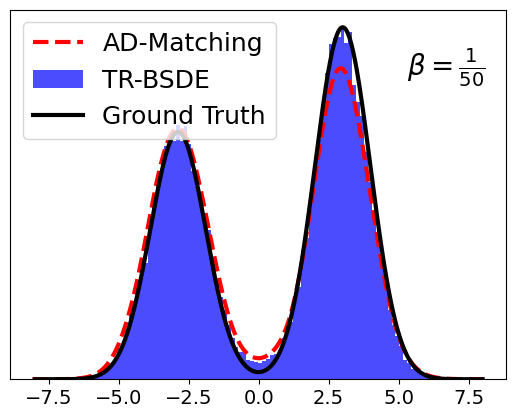

In [126]:
plt.figure()
# sns.kdeplot(X_f_tr[-1, :, 0].detach().numpy(), color='blue', linewidth=2, label='TR-BSDE')
sns.kdeplot(X_f_am[-1, :, 0].detach().numpy(), color='red', linewidth=3, label='AD-Matching', linestyle='--')
plt.hist(X_f_tr[-1, :, 0].detach().numpy(), bins=100, color='blue', alpha=0.7, density=True, label='TR-BSDE')
# plt.hist(X_f_am[-1, :, 0].detach().numpy(), bins=100, color='orange', alpha=0.1, density=True, label='AD-Matching')
plotx = torch.linspace(-8, 8, 1000)
Z = torch.trapz(tilted_pdf(plotx, temperature), plotx)
q = tilted_pdf(plotx, temperature)/Z
plt.plot(plotx.numpy(), q.numpy(), label='Ground Truth', color='black', linewidth=3)
plt.yticks([])
plt.ylabel("")
plt.legend(loc='upper left', fontsize=18)
plt.text(0.8, 0.9, r'$\beta=\frac{1}{50}$',
         transform=plt.gca().transAxes,
         fontsize=20,
         verticalalignment='top')
plt.savefig('figs/finetune_temp50_kde_beta.pdf', bbox_inches='tight')

In [127]:
temperature = 20.0
phi_iter = 5
Q_am = torch.load(f'network/finetune_admatching_Q_timesteps{steps}_utiter{phi_iter}_optiter{1000}_iteration{30}_temperature{temperature}_initialQ2_updateQmu6times.pth', weights_only=True)
mu_am = torch.load(f'network/finetune_admatching_mu_timesteps{steps}_utiter{phi_iter}_optiter{1000}_iteration{30}_temperature{temperature}_initialQ2_updateQmu6times.pth', weights_only=True)
ut_am = ScoreNetwork(input_dim=n+1, out_dim=n, hidden_dim=64, num_blocks=4)
ut_am.load_state_dict(torch.load(f'network/finetune_admatching_ut_timesteps{steps}_utiter{phi_iter}_optiter{1000}_iteration{30}_temperature{temperature}_initialQ2_updateQmu6times.pth', weights_only=True))
ut_am.eval()
Q_tr = torch.load(f'network/finetune_Q_timesteps{steps}_iteration{30}_phiiter{phi_iter}_optiter{1000}_temperature{temperature}_initialQ2_updateQmu6times_2score.pth', weights_only=True)
mu_tr = torch.load(f'network/finetune_mu_timesteps{steps}_iteration{30}_phiiter{phi_iter}_optiter{1000}_temperature{temperature}_initialQ2_updateQmu6times_2score.pth', weights_only=True)
phi_net_tr = ScoreNetwork(input_dim=n+1, out_dim=n, hidden_dim=64, num_blocks=4)
phi_net_tr.load_state_dict(torch.load(f'network/finetune_phi_network_timesteps{steps}_iteration{30}_phiiter{phi_iter}_optiter{1000}_temperature{temperature}_initialQ2_updateQmu6times_2score.pth', weights_only=True))
ut_tr = UNetFromPhi(phi_net_tr, g, temperature).eval()

Xi = torch.randn(N, n)
W_f = torch.randn(steps + 1, N, m) * torch.sqrt(torch.tensor(dt))
theta_am = Xi * Q_am + mu_am 
X_f_am = rollout(f, g, T, dt, theta_am, W_f, u_t=ut_am).detach()  # shape (steps+1, N, n)
theta_tr = Xi * Q_tr + mu_tr
X_f_tr = rollout(f, g, T, dt, theta_tr, W_f, u_t=ut_tr).detach()  # shape (steps+1, N, n)

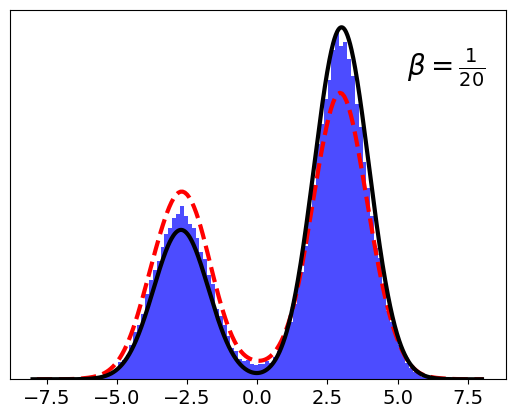

In [128]:
plt.figure()
plt.hist(X_f_tr[-1, :, 0].detach().numpy(), bins=100, color='blue', alpha=0.7, density=True, label='TR-BSDE')
# plt.hist(X_f_am[-1, :, 0].detach().numpy(), bins=100, color='orange', alpha=0.9, density=True, label='AD-Matching')
# sns.kdeplot(X_f_tr[-1, :, 0].detach().numpy(), color='blue', linewidth=2, label='TR-BSDE')
sns.kdeplot(X_f_am[-1, :, 0].detach().numpy(), color='red', linewidth=3, label='AD-Matching', linestyle='--')
plotx = torch.linspace(-8, 8, 1000)
Z = torch.trapz(tilted_pdf(plotx, temperature), plotx)
q = tilted_pdf(plotx, temperature)/Z
plt.plot(plotx.numpy(), q.numpy(), label='Ground Truth', color='black', linewidth=3)
plt.yticks([])
plt.ylabel("")
plt.text(0.8, 0.9, r'$\beta=\frac{1}{20}$',
         transform=plt.gca().transAxes,
         fontsize=20,
         verticalalignment='top')
plt.savefig('figs/finetune_temp20_kde_beta.pdf', bbox_inches='tight')
# plt.legend()

In [129]:
temperature = 6.0
phi_iter = 10
Q_am = torch.load(f'network/finetune_admatching_Q_timesteps{steps}_utiter{phi_iter}_optiter{1000}_iteration{30}_temperature{temperature}_initialQ2_updateQmu6times.pth', weights_only=True)
mu_am = torch.load(f'network/finetune_admatching_mu_timesteps{steps}_utiter{phi_iter}_optiter{1000}_iteration{30}_temperature{temperature}_initialQ2_updateQmu6times.pth', weights_only=True)
ut_am = ScoreNetwork(input_dim=n+1, out_dim=n, hidden_dim=64, num_blocks=4)
ut_am.load_state_dict(torch.load(f'network/finetune_admatching_ut_timesteps{steps}_utiter{phi_iter}_optiter{1000}_iteration{30}_temperature{temperature}_initialQ2_updateQmu6times.pth', weights_only=True))
ut_am.eval()
Q_tr = torch.load(f'network/finetune_Q_timesteps{steps}_iteration{30}_phiiter{phi_iter}_optiter{1000}_temperature{temperature}_initialQ2_updateQmu6times_2score.pth', weights_only=True)
mu_tr = torch.load(f'network/finetune_mu_timesteps{steps}_iteration{30}_phiiter{phi_iter}_optiter{1000}_temperature{temperature}_initialQ2_updateQmu6times_2score.pth', weights_only=True)
phi_net_tr = ScoreNetwork(input_dim=n+1, out_dim=n, hidden_dim=64, num_blocks=4)
phi_net_tr.load_state_dict(torch.load(f'network/finetune_phi_network_timesteps{steps}_iteration{30}_phiiter{phi_iter}_optiter{1000}_temperature{temperature}_initialQ2_updateQmu6times_2score.pth', weights_only=True))
ut_tr = UNetFromPhi(phi_net_tr, g, temperature).eval()

Xi = torch.randn(N, n)
W_f = torch.randn(steps + 1, N, m) * torch.sqrt(torch.tensor(dt))
theta_am = Xi * Q_am + mu_am 
X_f_am = rollout(f, g, T, dt, theta_am, W_f, u_t=ut_am).detach()  # shape (steps+1, N, n)
theta_tr = Xi * Q_tr + mu_tr
X_f_tr = rollout(f, g, T, dt, theta_tr, W_f, u_t=ut_tr).detach()  # shape (steps+1, N, n)

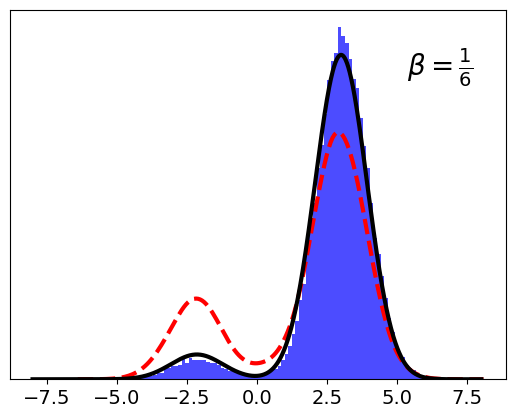

In [130]:
plt.figure()
# plt.hist(X_f_am[-1, :, 0].detach().numpy(), bins=100, color='orange', alpha=0.9, density=True, label='AD-Matching')
plt.hist(X_f_tr[-1, :, 0].detach().numpy(), bins=100, color='blue', alpha=0.7, density=True, label='TR-BSDE')
# plt.hist(X_f_am[-1, :, 0].detach().numpy(), bins=100, color='orange', alpha=0.9, density=True, label='AD-Matching')
# sns.kdeplot(X_f_tr[-1, :, 0].detach().numpy(), color='blue', linewidth=2, label='TR-BSDE')
sns.kdeplot(X_f_am[-1, :, 0].detach().numpy(), color='red', linewidth=3, label='AD-Matching', linestyle='--')
plotx = torch.linspace(-8, 8, 1000)
Z = torch.trapz(tilted_pdf(plotx, temperature), plotx)
q = tilted_pdf(plotx, temperature)/Z
plt.plot(plotx.numpy(), q.numpy(), label='Ground Truth', color='black', linewidth=3)
plt.yticks([])
plt.ylabel("")
plt.text(0.8, 0.9, r'$\beta=\frac{1}{6}$',
         transform=plt.gca().transAxes,
         fontsize=20,
         verticalalignment='top')
plt.savefig('figs/finetune_temp6_kde_beta.pdf', bbox_inches='tight')
# plt.legend()

In [131]:
temperature = 1.0
phi_iter = 10
Q_am = torch.load(f'network/finetune_admatching_Q_timesteps{steps}_utiter{phi_iter}_optiter{1000}_iteration{30}_temperature{temperature}_initialQ2_updateQmu6times.pth', weights_only=True)
mu_am = torch.load(f'network/finetune_admatching_mu_timesteps{steps}_utiter{phi_iter}_optiter{1000}_iteration{30}_temperature{temperature}_initialQ2_updateQmu6times.pth', weights_only=True)
ut_am = ScoreNetwork(input_dim=n+1, out_dim=n, hidden_dim=64, num_blocks=4)
ut_am.load_state_dict(torch.load(f'network/finetune_admatching_ut_timesteps{steps}_utiter{phi_iter}_optiter{1000}_iteration{30}_temperature{temperature}_initialQ2_updateQmu6times.pth', weights_only=True))
ut_am.eval()
Q_tr = torch.load(f'network/finetune_Q_timesteps{steps}_iteration{30}_phiiter{phi_iter}_optiter{1000}_temperature{temperature}_initialQ2_updateQmu6times_2score.pth', weights_only=True)
mu_tr = torch.load(f'network/finetune_mu_timesteps{steps}_iteration{30}_phiiter{phi_iter}_optiter{1000}_temperature{temperature}_initialQ2_updateQmu6times_2score.pth', weights_only=True)
phi_net_tr = ScoreNetwork(input_dim=n+1, out_dim=n, hidden_dim=64, num_blocks=4)
phi_net_tr.load_state_dict(torch.load(f'network/finetune_phi_network_timesteps{steps}_iteration{30}_phiiter{phi_iter}_optiter{1000}_temperature{temperature}_initialQ2_updateQmu6times_2score.pth', weights_only=True))
ut_tr = UNetFromPhi(phi_net_tr, g, temperature).eval()

Xi = torch.randn(N, n)
W_f = torch.randn(steps + 1, N, m) * torch.sqrt(torch.tensor(dt))
theta_am = Xi * Q_am + mu_am 
X_f_am = rollout(f, g, T, dt, theta_am, W_f, u_t=ut_am).detach()  # shape (steps+1, N, n)
theta_tr = Xi * Q_tr + mu_tr
X_f_tr = rollout(f, g, T, dt, theta_tr, W_f, u_t=ut_tr).detach()  # shape (steps+1, N, n)

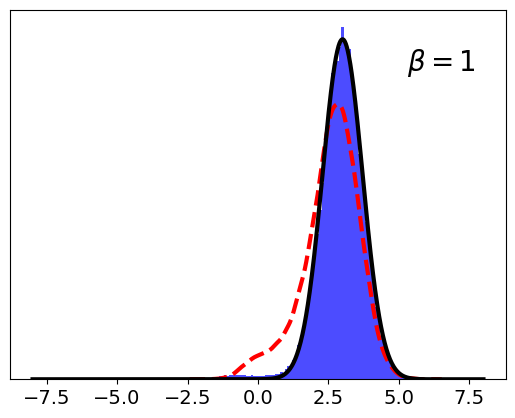

In [132]:
plt.figure()
# plt.hist(X_f_am[-1, :, 0].detach().numpy(), bins=100, color='orange', alpha=0.7, density=True, label='AD-Matching')
plt.hist(X_f_tr[-1, :, 0].detach().numpy(), bins=100, color='blue', alpha=0.7, density=True, label='TR-BSDE')
# plt.hist(X_f_am[-1, :, 0].detach().numpy(), bins=100, color='orange', alpha=0.7, density=True, label='AD-Matching')
# sns.kdeplot(X_f_tr[-1, :, 0].detach().numpy(), color='blue', linewidth=2, label='TR-BSDE')
sns.kdeplot(X_f_am[-1, :, 0].detach().numpy(), color='red', linewidth=3, label='AD-Matching', linestyle='--')
plotx = torch.linspace(-8, 8, 1000)
Z = torch.trapz(tilted_pdf(plotx, temperature), plotx)
q = tilted_pdf(plotx, temperature)/Z
plt.plot(plotx.numpy(), q.numpy(), label='Ground Truth', color='black', linewidth=3)
plt.yticks([])
plt.ylabel("")
plt.text(0.8, 0.9, r'$\beta=1$',
         transform=plt.gca().transAxes,
         fontsize=20,
         verticalalignment='top')
plt.savefig('figs/finetune_temp1_kde_beta.pdf', bbox_inches='tight')
# plt.legend()

In [32]:
cost_wrt_temp_am = []
cost_wrt_temp_tr = []
for temperature in temperature_list:
    if temperature in [50.0, 20.0, 8.0]:
        phi_iter = 5
    else:
        phi_iter = 10
    Q_am = torch.load(f'network/finetune_admatching_Q_timesteps{steps}_utiter{phi_iter}_optiter{1000}_iteration{30}_temperature{temperature}_initialQ2_updateQmu6times.pth')
    mu_am = torch.load(f'network/finetune_admatching_mu_timesteps{steps}_utiter{phi_iter}_optiter{1000}_iteration{30}_temperature{temperature}_initialQ2_updateQmu6times.pth')
    ut_am = ScoreNetwork(input_dim=n+1, out_dim=n, hidden_dim=64, num_blocks=4)
    ut_am.load_state_dict(torch.load(f'network/finetune_admatching_ut_timesteps{steps}_utiter{phi_iter}_optiter{1000}_iteration{30}_temperature{temperature}_initialQ2_updateQmu6times.pth'))
    ut_am.eval()
    Q_tr = torch.load(f'network/finetune_Q_timesteps{steps}_iteration{30}_phiiter{phi_iter}_optiter{1000}_temperature{temperature}_initialQ2_updateQmu6times_2score.pth')
    mu_tr = torch.load(f'network/finetune_mu_timesteps{steps}_iteration{30}_phiiter{phi_iter}_optiter{1000}_temperature{temperature}_initialQ2_updateQmu6times_2score.pth')
    phi_net_tr = ScoreNetwork(input_dim=n+1, out_dim=n, hidden_dim=64, num_blocks=4)
    phi_net_tr.load_state_dict(torch.load(f'network/finetune_phi_network_timesteps{steps}_iteration{30}_phiiter{phi_iter}_optiter{1000}_temperature{temperature}_initialQ2_updateQmu6times_2score.pth'))
    ut_tr = UNetFromPhi(phi_net_tr, g, temperature).eval()

    
    Xi = torch.randn(N, n)
    W_f = torch.randn(steps + 1, N, m) * torch.sqrt(torch.tensor(dt))
    theta_am = Xi * Q_am + mu_am 
    X_f_am = rollout(f, g, T, dt, theta_am, W_f, u_t=ut_am).detach()  # shape (steps+1, N, n)
    theta_tr = Xi * Q_tr + mu_tr
    X_f_tr = rollout(f, g, T, dt, theta_tr, W_f, u_t=ut_tr).detach()  # shape (steps+1, N, n)


    ## Comput costs 
    # terminal cost
    terminal_cost_am = lf(X_f_am[-1,:,:])/temperature  # shape (N,)
    terminal_cost_tr = lf(X_f_tr[-1,:,:])/temperature  # shape (N,)

    # running cost
    X_f_am_flat = X_f_am.reshape(-1, n)  # shape ((steps+1)*N, n)
    X_f_tr_flat = X_f_tr.reshape(-1, n)  # shape ((steps+1)*N, n)
    time_flat = time_repeated.unsqueeze(-1).reshape(-1, 1)  # shape ((steps+1)*N, 1)
    u_am = ut_am(X_f_am_flat, time_flat).detach().reshape(steps+1, N, m)  # shape ((steps+1)*N, m)
    u_tr = ut_tr(X_f_tr_flat, time_flat).detach().reshape(steps+1, N, m)  # shape ((steps+1)*N, m)
    running_cost_am = (u_am**2*dt).sum(dim=(0,2)) * 0.5  # shape (N,)
    running_cost_tr = (u_tr**2*dt).sum(dim=(0,2)) * 0.5   # shape (N,)

    # kl divergence cost
    mean_am = theta_am.mean(dim=0, keepdim=True)  
    temp_am = theta_am - mean_am.repeat(theta_am.shape[0], 1) 
    var_am = (temp_am.T @ temp_am) / (N - 1)  
    var_am = Q_am.clone().detach() @ Q_am.clone().detach().T  
    kl_cost_am =  0.5 * (torch.trace(var_am) + mean_am @ mean_am.T - 1 - torch.logdet(var_am))  
    mean_tr = theta_tr.mean(dim=0, keepdim=True)
    temp_tr = theta_tr - mean_tr.repeat(theta_tr.shape[0], 1)
    var_tr = (temp_tr.T @ temp_tr) / (N - 1)
    var_tr = Q_tr.clone().detach() @ Q_tr.clone().detach().T
    kl_cost_tr = 0.5 * (torch.trace(var_tr) + mean_tr @ mean_tr.T - 1 - torch.logdet(var_tr))


    # total cost
    total_cost_am = (terminal_cost_am + running_cost_am + kl_cost_am).mean()  
    total_cost_tr = (terminal_cost_tr + running_cost_tr + kl_cost_tr).mean()
    cost_wrt_temp_am.append(total_cost_am.item())
    cost_wrt_temp_tr.append(total_cost_tr.item())

/var/folders/pd/hp6m3j2j5v9bd6w64h7wl3rm0000gn/T/ipykernel_13832/720835772.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  Q_am = torch.load(f'network/finetune_admatchin

In [34]:
beta = 1/np.array(temperature_list)

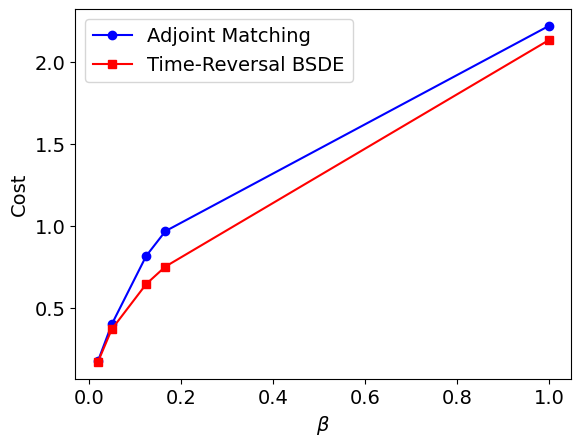

In [42]:
plt.figure()
plt.plot(beta, cost_wrt_temp_am, label='Adjoint Matching', color='blue', marker='o')
plt.plot(beta, cost_wrt_temp_tr, label='Time-Reversal BSDE', color='red', marker='s')
plt.xlabel(r'$\beta$')
plt.ylabel('Cost')
# plt.yscale('log')
plt.legend()
plt.savefig('figs/Compare_cost_vs_beta.pdf', bbox_inches='tight')